# Connect 4 – CNN v2 (Improved Training)

**Upgrades over v1:**
1. **Logits + `CategoricalCrossentropy(from_logits=True)`** — more numerically stable, better gradients
2. **Convolutional policy head** — replaces the massive Dense(1024)→Dense(512) stack (~6M params → ~50K params)
3. **Connect-4-shaped multi-kernel stem** — parallel (1×4) and (4×1) convolutions capture horizontal/vertical threats explicitly
4. **Entropy-weighted training** — upweights strategically interesting positions, downweights forced/trivial ones
5. **Logit-masking of illegal moves during training** — training now matches inference behavior
6. **AdamW + cosine LR decay** — cleaner regularization, better convergence
7. **KL Divergence + Top-2 Accuracy metrics** — more meaningful than single-move accuracy on a distribution target

**Dataset expected:** `dean800k.npz` with keys `X` (N, 6, 7) and `pi` (N, 7)

## 1. Setup & Data Loading

In [7]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))


2.20.0-rc0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
[]


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers, callbacks
import os
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0-rc0
GPU available: False


In [4]:
file_path = 'dean800k.npz'

# ==========================================
# DATA LOADING & PREPROCESSING
# ==========================================
if os.path.exists(file_path):
    print(f"Loading {file_path}...")
    with np.load(file_path) as data:
        X_raw = data['X']    # Shape: (N, 6, 7)  -- board states (already flipped to plus-perspective)
        pi    = data['pi']   # Shape: (N, 7)     -- MCTS move probability distribution

    # Convert board to dual-channel representation (N, 6, 7, 2)
    #   Channel 0: current player's pieces  (+1 squares → 1.0)
    #   Channel 1: opponent's pieces        (-1 squares → 1.0)
    # This lets the network learn "my pattern" vs "their pattern" independently.
    X = np.zeros((X_raw.shape[0], 6, 7, 2), dtype=np.float32)
    X[..., 0] = (X_raw ==  1).astype(np.float32)  # my pieces
    X[..., 1] = (X_raw == -1).astype(np.float32)  # opponent pieces

    pi = pi.astype(np.float32)

    print(f"Board input shape : {X.shape}")
    print(f"Target (pi) shape : {pi.shape}")
    print(f"Pi sum check (should be ~1.0): {pi.sum(axis=1).mean():.4f}")
else:
    raise FileNotFoundError(f"Dataset not found at '{file_path}'. Upload it before running.")

Loading dean800k.npz...
Board input shape : (840586, 6, 7, 2)
Target (pi) shape : (840586, 7)
Pi sum check (should be ~1.0): 1.0000


## 2. Build a Legal-Move Mask

We can infer which columns are legal from the board state itself: a column is legal if its top row (`row 0`) is empty (== 0 in both channels).

In [5]:
# Legal mask: column is legal iff top row has no piece for either player
# X_raw row 0 = 0 means empty top → column is available
legal_mask = ((X_raw[:, 0, :] == 0)).astype(np.float32)  # Shape: (N, 7)
print(f"Legal mask shape: {legal_mask.shape}")
print(f"Average legal moves per position: {legal_mask.sum(axis=1).mean():.2f}")

Legal mask shape: (840586, 7)
Average legal moves per position: 5.51


## 3. Entropy-Based Sample Weighting

Not all positions are equally informative to train on:
- **Low entropy** (one move ~1.0): forced / trivial positions. The network learns little strategy here.
- **Medium entropy** (several good moves): the most strategically rich positions — upweight these.
- **High entropy** (all moves ~equal): very early game or lost positions — less useful signal.

We weight by a soft bell centered around medium entropy.

Entropy stats:
  Min:  0.0000
  Mean: 1.1929
  Max:  1.9454
  Max possible (log 7): 1.9459

Sample weight stats:
  Min:  0.0500
  Mean: 0.5601
  Max:  1.0000


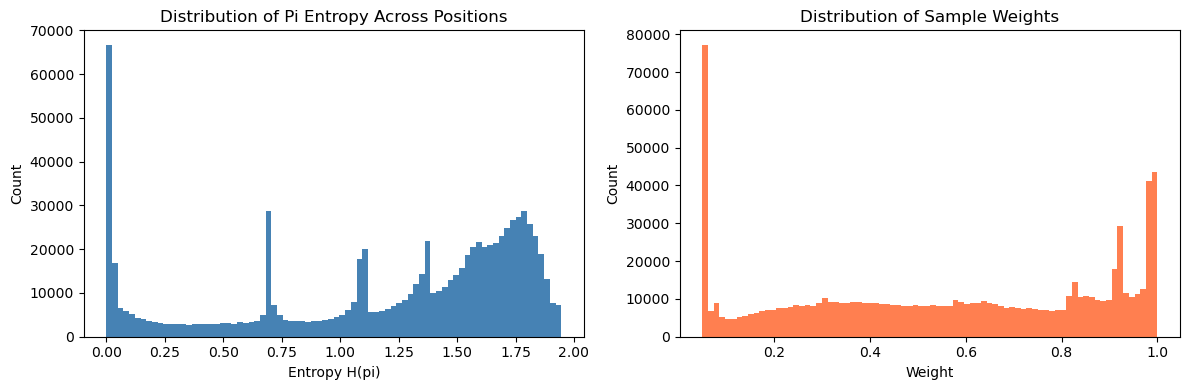

In [6]:
# Compute Shannon entropy H(pi) for each position
# Clip to avoid log(0)
pi_clipped = np.clip(pi, 1e-9, 1.0)
entropy = -np.sum(pi_clipped * np.log(pi_clipped), axis=1)  # Shape: (N,)
max_entropy = np.log(7)  # Maximum possible entropy for 7 columns

print(f"Entropy stats:")
print(f"  Min:  {entropy.min():.4f}")
print(f"  Mean: {entropy.mean():.4f}")
print(f"  Max:  {entropy.max():.4f}")
print(f"  Max possible (log 7): {max_entropy:.4f}")

# Normalize entropy to [0, 1]
entropy_norm = entropy / max_entropy

# Soft bell weighting: reward medium entropy, discount trivial (near 0) and uniform (near 1)
# w(e) = 4 * e * (1 - e)  — peaks at 0.5, goes to 0 at extremes
sample_weights = 4.0 * entropy_norm * (1.0 - entropy_norm)
sample_weights = np.clip(sample_weights, 0.05, 1.0)  # floor at 0.05 so nothing is entirely ignored

print(f"\nSample weight stats:")
print(f"  Min:  {sample_weights.min():.4f}")
print(f"  Mean: {sample_weights.mean():.4f}")
print(f"  Max:  {sample_weights.max():.4f}")

# Visualize entropy distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(entropy, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution of Pi Entropy Across Positions')
axes[0].set_xlabel('Entropy H(pi)')
axes[0].set_ylabel('Count')
axes[1].hist(sample_weights, bins=80, color='coral', edgecolor='none')
axes[1].set_title('Distribution of Sample Weights')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. CNN v2 Architecture

### Key design decisions:

**Multi-kernel stem:** Parallel convolutions with (3×3), (1×4), and (4×1) kernels explicitly encode the 3 types of Connect-4 threats right from the first layer. Their outputs are concatenated before entering the residual tower.

**Residual tower:** 5 blocks of (Conv→BN→ELU→Conv→BN→Add→ELU), same as v1, at 128 filters. No pooling — the 6×7 board is too small.

**Convolutional policy head:** Instead of Flatten→Dense(1024)→Dense(512)→Dense(7), we use Conv2D(32, 1×1)→BN→ELU→Flatten→Dense(7 logits). This drops from ~6M parameters in the head to ~50K while preserving spatial relationships longer.

**Raw logits output:** No softmax in the model. The loss (`CategoricalCrossentropy(from_logits=True)`) applies it internally for numerical stability. At inference time, we apply softmax manually.

In [ ]:
def res_block(tensor, filters, kernel_size=(3, 3), reg_strength=1e-5):
    """
    Standard residual block: Conv→BN→ELU→Conv→BN→Add→ELU
    No projection needed because filters stay constant throughout the tower.
    """
    shortcut = tensor
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(reg_strength))(tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(reg_strength))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation('elu')(x)
    return x


def create_cnn_v2(input_shape=(6, 7, 2), num_outputs=7, filters=128,
                  num_res_blocks=5, l2_reg=1e-5):
    """
    Connect-4 CNN v2:
      - Multi-kernel stem with (3x3) + (1x4) + (4x1) parallel convolutions
      - Deep residual tower
      - Compact convolutional policy head
      - Raw logit output (no softmax — applied in loss)
    """
    inputs = layers.Input(shape=input_shape)

    # -------------------------------------------------------
    # MULTI-KERNEL STEM
    # Captures 3x3 local patterns + horizontal (1x4) threats +
    # vertical (4x1) threats simultaneously.
    # All branches use 'same' padding to preserve spatial size.
    # -------------------------------------------------------
    branch_33 = layers.Conv2D(filters // 2, (3, 3), padding='same', use_bias=False,
                               kernel_regularizer=regularizers.l2(l2_reg))(inputs)

    branch_14 = layers.Conv2D(filters // 4, (1, 4), padding='same', use_bias=False,
                               kernel_regularizer=regularizers.l2(l2_reg))(inputs)

    branch_41 = layers.Conv2D(filters // 4, (4, 1), padding='same', use_bias=False,
                               kernel_regularizer=regularizers.l2(l2_reg))(inputs)

    # Concatenate along channel axis → total channels = filters
    x = layers.Concatenate()([branch_33, branch_14, branch_41])
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)

    # -------------------------------------------------------
    # RESIDUAL TOWER
    # -------------------------------------------------------
    for _ in range(num_res_blocks):
        x = res_block(x, filters=filters, reg_strength=l2_reg)

    # -------------------------------------------------------
    # CONVOLUTIONAL POLICY HEAD
    # 1x1 conv compresses channels, then we flatten and project to 7 logits.
    # Much cheaper than Dense(1024)→Dense(512) and preserves spatial info longer.
    # -------------------------------------------------------
    x = layers.Conv2D(32, (1, 1), padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)

    x = layers.Flatten()(x)

    # Raw logits — NO softmax here
    # Softmax is applied inside CategoricalCrossentropy(from_logits=True) during training
    # and manually at inference for stability.
    logits = layers.Dense(num_outputs, activation=None,
                          kernel_regularizer=regularizers.l2(l2_reg),
                          name='logits')(x)

    return models.Model(inputs, logits, name="Connect4_CNN_v2")


# Build and inspect
model = create_cnn_v2(input_shape=(6, 7, 2), num_outputs=7, filters=128, num_res_blocks=5, l2_reg=1e-5)
model.summary()

## 5. Custom Loss: Masked Logit Cross-Entropy

During training, we mask illegal columns by setting their logits to a large negative value before computing softmax inside the loss. This exactly replicates what we do at inference time, making training and inference consistent.

In [ ]:
class MaskedCategoricalCrossentropy(tf.keras.losses.Loss):
    """
    Cross-entropy loss that applies an illegal-move mask before computing softmax.
    
    legal_mask is passed as part of y_true: we concatenate [pi | legal_mask]
    along the last axis during preprocessing so both travel through model.fit().
    """
    def call(self, y_true, y_pred):
        # y_true shape: (batch, 14) — first 7 are pi, last 7 are legal_mask
        pi_target   = y_true[:, :7]    # (batch, 7) probability distribution
        mask        = y_true[:, 7:]    # (batch, 7) 1=legal, 0=illegal

        # Mask illegal logits with a large negative number
        masked_logits = y_pred + (1.0 - mask) * (-1e9)

        # Cross-entropy from logits (numerically stable)
        loss = tf.nn.softmax_cross_entropy_with_logits(
            labels=pi_target,
            logits=masked_logits
        )
        return loss


# Package targets: stack pi + legal_mask → shape (N, 14)
y_combined = np.concatenate([pi, legal_mask], axis=1).astype(np.float32)
print(f"Combined target shape: {y_combined.shape}  (pi | legal_mask)")

## 6. Custom Metrics

Since our target is a full distribution, tracking single-move accuracy is misleading. We use:
- **KL Divergence** — measures how well the model's distribution matches MCTS's distribution  
- **Top-2 Accuracy** — does the model's best predicted move appear in MCTS's top-2 moves? This is a better proxy for actual play quality.

In [ ]:
class MaskedKLDivergence(tf.keras.metrics.Metric):
    """
    KL(pi_target || model_pi) over legal moves.
    Lower is better. Zero means perfect match.
    """
    def __init__(self, name='kl_divergence', **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name='total', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        pi_target = y_true[:, :7]
        mask      = y_true[:, 7:]
        masked_logits = y_pred + (1.0 - mask) * (-1e9)
        model_pi = tf.nn.softmax(masked_logits)
        # KL = sum(p * log(p/q)) over legal moves
        kl = tf.reduce_sum(
            pi_target * tf.math.log(tf.clip_by_value(pi_target, 1e-9, 1.0) /
                                     tf.clip_by_value(model_pi, 1e-9, 1.0)),
            axis=1
        )
        self.total.assign_add(tf.reduce_sum(kl))
        self.count.assign_add(tf.cast(tf.shape(kl)[0], tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)


class MaskedTop2Accuracy(tf.keras.metrics.Metric):
    """
    Fraction of examples where argmax(model_pi) is in the top-2 of pi_target.
    A model that always picks a reasonable move will score highly here.
    """
    def __init__(self, name='top2_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.count   = self.add_weight(name='count',   initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        pi_target = y_true[:, :7]
        mask      = y_true[:, 7:]
        masked_logits = y_pred + (1.0 - mask) * (-1e9)
        model_best = tf.argmax(masked_logits, axis=1)  # model's top-1 choice
        top2_targets = tf.math.top_k(pi_target, k=2).indices  # MCTS top-2 moves
        # Check if model_best appears in top-2 targets
        model_best_exp = tf.expand_dims(model_best, axis=1)  # (batch, 1)
        matches = tf.reduce_any(tf.equal(model_best_exp, top2_targets), axis=1)
        self.correct.assign_add(tf.reduce_sum(tf.cast(matches, tf.float32)))
        self.count.assign_add(tf.cast(tf.shape(matches)[0], tf.float32))

    def result(self):
        return self.correct / self.count

    def reset_state(self):
        self.correct.assign(0.0)
        self.count.assign(0.0)


print("Custom loss and metrics defined.")

## 7. Compile & Train

In [ ]:
# ==========================================
# TRAINING CONFIGURATION
# ==========================================
BATCH_SIZE    = 512    # Larger batch = faster + more stable gradients (use 256 if OOM)
EPOCHS        = 60
LR_INITIAL    = 3e-4   # Slightly higher start; cosine decay brings it down
WARMUP_EPOCHS = 3      # Linear warmup before cosine decay kicks in
VAL_SPLIT     = 0.1

N_TRAIN = int(len(X) * (1 - VAL_SPLIT))
STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS

print(f"Training samples   : {N_TRAIN:,}")
print(f"Validation samples : {len(X) - N_TRAIN:,}")
print(f"Steps per epoch    : {STEPS_PER_EPOCH:,}")
print(f"Total steps        : {TOTAL_STEPS:,}")

In [ ]:
# Cosine decay learning rate schedule with linear warmup
# Warmup: LR grows linearly from 0 → LR_INITIAL over first WARMUP_EPOCHS epochs
# Decay:  LR follows cosine curve from LR_INITIAL → ~0 over remaining epochs

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LR_INITIAL,
    first_decay_steps=STEPS_PER_EPOCH * (EPOCHS - WARMUP_EPOCHS),
    t_mul=1.0,
    m_mul=0.9,
    alpha=1e-6  # Minimum LR floor
)

# AdamW: Adam + decoupled weight decay (cleaner than L2 regularizer on every layer)
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4  # Separate from per-layer L2 regularizers
)

model.compile(
    optimizer=optimizer,
    loss=MaskedCategoricalCrossentropy(),
    metrics=[
        MaskedKLDivergence(),
        MaskedTop2Accuracy()
    ]
)

# Callbacks
callbacks_list = [
    # Save the best model by val KL divergence (lower = better distribution match)
    callbacks.ModelCheckpoint(
        filepath='connect4_cnn_v2_best.keras',
        monitor='val_kl_divergence',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    # Early stopping with more patience than v1 — LR decay makes late improvements possible
    callbacks.EarlyStopping(
        monitor='val_kl_divergence',
        patience=10,
        restore_best_weights=True,
        mode='min',
        verbose=1
    ),
    # Log LR each epoch for visibility
    callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: logs.update(
            {'lr': float(optimizer.learning_rate(optimizer.iterations))}
        )
    )
]

print("Model compiled successfully.")

In [ ]:
# ==========================================
# TRAIN
# ==========================================
history = model.fit(
    X,
    y_combined,              # (N, 14): pi concatenated with legal_mask
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    sample_weight=sample_weights,  # Entropy-based importance weighting
    callbacks=callbacks_list,
    verbose=1,
    shuffle=True
)

In [ ]:
# Save final model
model.save('connect4_cnn_v2_final.keras')
print("Final model saved to 'connect4_cnn_v2_final.keras'")
print("Best model (by val KL) saved to 'connect4_cnn_v2_best.keras'")

## 8. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Masked Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KL Divergence
axes[1].plot(history.history['kl_divergence'], label='Train KL')
axes[1].plot(history.history['val_kl_divergence'], label='Val KL')
axes[1].set_title('KL Divergence (lower = better distribution match)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Top-2 Accuracy
axes[2].plot(history.history['top2_accuracy'], label='Train Top-2 Acc')
axes[2].plot(history.history['val_top2_accuracy'], label='Val Top-2 Acc')
axes[2].set_title('Top-2 Accuracy (model picks a move in MCTS top-2)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Connect-4 CNN v2 Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training curves to 'training_curves_v2.png'")

## 9. Inference Helper

This is the function you'll call from your Anvil/AWS backend. It takes the raw board (6×7, +1/-1/0), applies the player-perspective flip if needed, and returns the model's chosen column.

In [ ]:
def get_model_move(model, board, player='plus'):
    """
    Given a raw board (6x7 array, +1/-1/0) and the current player,
    returns the column the model recommends.

    Args:
        model   : Loaded Keras model (outputs raw logits)
        board   : np.ndarray (6, 7) with +1 (plus), -1 (minus), 0 (empty)
        player  : 'plus' or 'minus' — whose turn it is

    Returns:
        int: column index 0-6
    """
    # The model is always trained from the 'plus' player's perspective.
    # If minus is moving, flip the board so plus is the active player.
    b = board.copy()
    if player == 'minus':
        b = b * -1

    # Build dual-channel input
    X_input = np.zeros((1, 6, 7, 2), dtype=np.float32)
    X_input[0, :, :, 0] = (b ==  1).astype(np.float32)  # my pieces
    X_input[0, :, :, 1] = (b == -1).astype(np.float32)  # opponent pieces

    # Get raw logits from model
    logits = model.predict(X_input, verbose=0)[0]  # shape (7,)

    # Mask illegal columns (column is illegal if top row is occupied)
    for col in range(7):
        if board[0, col] != 0:
            logits[col] = -1e9

    # Softmax over legal logits → probability distribution
    logits_shifted = logits - np.max(logits)  # numerical stability
    probs = np.exp(logits_shifted)
    probs /= probs.sum()

    return int(np.argmax(probs))


# Quick sanity check on an empty board
import numpy as np
test_board = np.zeros((6, 7))
best_col = get_model_move(model, test_board, player='plus')
print(f"Model recommends column {best_col} on an empty board (usually 3 = center)")

## 10. Quick Benchmark vs. MCTS

Play the trained model against weak MCTS (300 steps) to evaluate practical strength. The model wins or draws more often than it loses if training went well.

In [ ]:
# NOTE: This cell requires the MCTS functions from the original notebook.
# Paste or import: update_board, check_for_win, find_legal, mcts
# (They are unchanged from the original Connect4.ipynb)

# Uncomment and run once those functions are available:
"""
import random

def play_model_vs_mcts(model, mcts_steps=300, n_games=50):
    results = {'model_win': 0, 'mcts_win': 0, 'draw': 0}

    for game_i in range(n_games):
        board = np.zeros((6, 7))
        winner = 'nobody'
        turn = 'plus'   # Model plays as 'plus', MCTS plays as 'minus'
        # Randomly decide who goes first for diversity
        if random.random() < 0.5:
            model_color = 'plus'
        else:
            model_color = 'minus'
        mcts_color = 'minus' if model_color == 'plus' else 'plus'

        while winner == 'nobody':
            if turn == model_color:
                col = get_model_move(model, board, player=model_color)
            else:
                col = mcts(board, turn, mcts_steps)

            board = update_board(board, turn, col)
            winner = check_for_win(board, col)

            if len(find_legal(board)) == 0 and winner == 'nobody':
                winner = 'tie'

            turn = 'minus' if turn == 'plus' else 'plus'

        if winner == 'tie':
            results['draw'] += 1
        elif winner[2:] == model_color[0]:  # winner string is e.g. 'h-plus'
            results['model_win'] += 1
        else:
            results['mcts_win'] += 1

        if (game_i + 1) % 10 == 0:
            print(f"Game {game_i+1}/{n_games}: {results}")

    print(f"\n=== Results after {n_games} games vs MCTS({mcts_steps}) ===")
    print(f"Model wins : {results['model_win']} ({100*results['model_win']/n_games:.1f}%)")
    print(f"MCTS wins  : {results['mcts_win']} ({100*results['mcts_win']/n_games:.1f}%)")
    print(f"Draws      : {results['draw']} ({100*results['draw']/n_games:.1f}%)")
    return results

play_model_vs_mcts(model, mcts_steps=300, n_games=50)
"""

print("Benchmark cell ready — uncomment after pasting MCTS functions.")